<a href="https://colab.research.google.com/github/Sweper27/244107020175-Mesin-Learning/blob/main/Jobsheet4/TugasPraktikum(JS4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-MEANS**

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Pengaturan visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
# 1. Membaca dataset Mall Customers
df = pd.read_csv('/content/Mall_Customers.csv')

# Menampilkan 5 data pertama untuk inspeksi awal
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
# 2. Memeriksa informasi dan struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
# 3. Memilih fitur utama untuk clustering (Annual Income dan Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
display(X.head())

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [11]:
# 4. Standardisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengonversi kembali ke DataFrame untuk kemudahan visualisasi data terstandardisasi
X_scaled_df = pd.DataFrame(X_scaled, columns=['Annual Income', 'Spending Score'])
display(X_scaled_df.head())

,Annual Income,Spending Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [12]:
# 5. Menentukan Jumlah Cluster Optimal dengan Elbow Method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

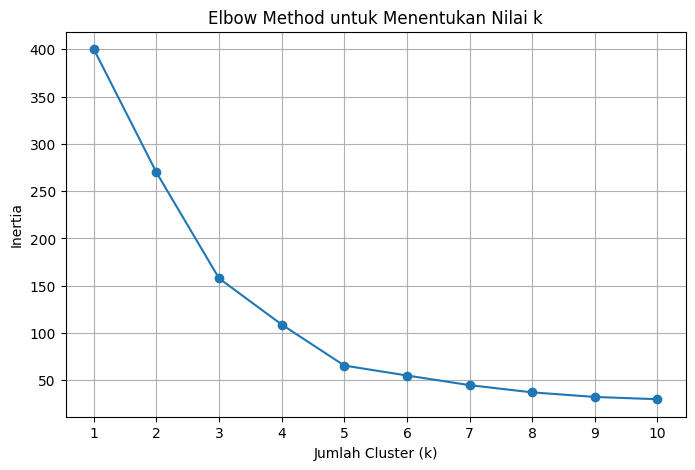

In [14]:
# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Nilai k Optimal')
plt.xticks(K)
plt.grid(True)
plt.show()

In [16]:
# 6. Membangun Model K-Means dengan k=5 (Optimal)
k_optimal = 5
kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=10
)

# Melatih model dan memprediksi label cluster
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels

display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


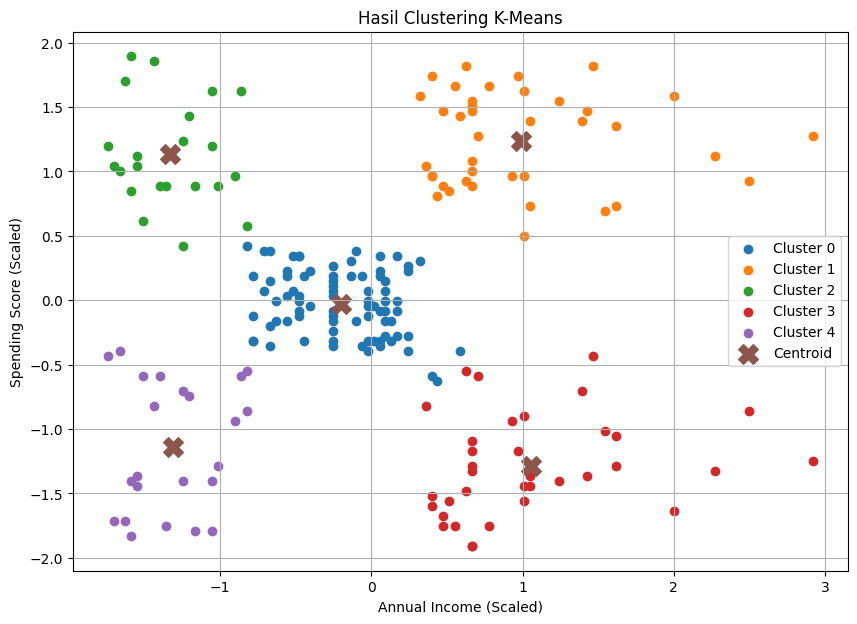

In [17]:
# 7. Visualisasi Hasil Clustering
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))
for cluster_id in range(k_optimal):
    cluster_data = X_scaled[labels == cluster_id]
    plt.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        s=50,
        label=f'Cluster {cluster_id}'
    )

# Menampilkan Centroid
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    color='black',
    edgecolors='white',
    label='Centroids'
)

plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.title('Visualisasi Segmentasi Pelanggan (K-Means)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [18]:
# 8. Analisis Distribusi Anggota Cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
print("Jumlah anggota pada masing-masing cluster:")
print(cluster_counts)

Jumlah anggota setiap cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [19]:
# 9. Ringkasan Karakteristik (Mean) dari Setiap Cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


# **DBSCAN**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [21]:
# Membuat dataset make_moons
X, y = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# Menampilkan bentuk dataset
print("Jumlah data:", X.shape[0])
print("Jumlah fitur:", X.shape[1])

Jumlah data: 1000
Jumlah fitur: 2


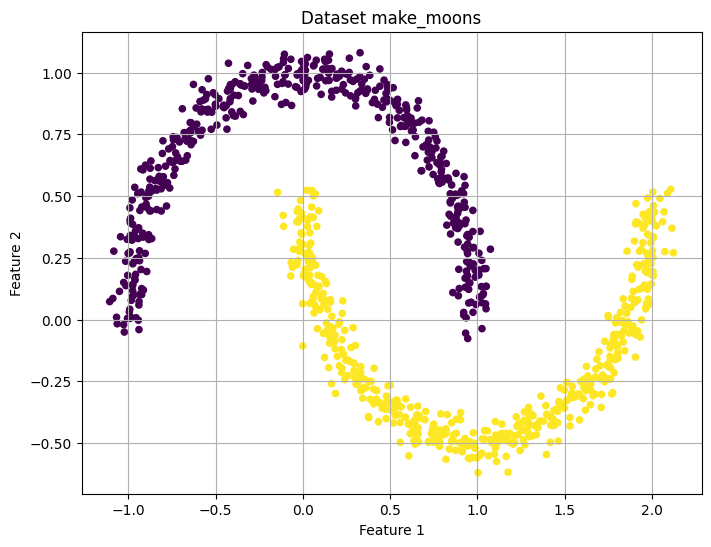

In [22]:
# Visualisasi dataset sebelum clustering
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=20
)

plt.title("Dataset make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

In [23]:
# Membuat objek StandardScaler
scaler = StandardScaler()

# Melakukan normalisasi
X_scaled = scaler.fit_transform(X)

# Menampilkan hasil normalisasi
print("Data setelah normalisasi:")
print(X_scaled[:5])

Data setelah normalisasi:
[[-0.59996716  0.31757343]
 [ 0.55020965 -1.42528284]
 [ 0.46649751 -1.26036633]
 [-0.14046604 -1.30173005]
 [-1.54557314  0.56836644]]


In [24]:
# Membuat model DBSCAN
db = DBSCAN(
    eps=0.2,
    min_samples=5
)

# Melakukan clustering
labels = db.fit_predict(X_scaled)

# Mengambil label cluster unik
unique_labels = set(labels)

print("Label cluster:", unique_labels)

Label cluster: {np.int64(0), np.int64(1)}


In [25]:
# Menghitung jumlah cluster
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Menghitung jumlah noise
n_noise = list(labels).count(-1)

print("Jumlah cluster :", n_clusters)
print("Jumlah noise   :", n_noise)

Jumlah cluster : 2
Jumlah noise   : 0


In [34]:
# Menghitung metrik evaluasi clustering
homogeneity = metrics.homogeneity_score(y, labels)
completeness = metrics.completeness_score(y, labels)
v_measure = metrics.v_measure_score(y, labels)
ari = metrics.adjusted_rand_score(y, labels)
ami = metrics.adjusted_mutual_info_score(y, labels)
silhouette = metrics.silhouette_score(X_scaled, labels)

# Menampilkan hasil evaluasi
print("=== HASIL EVALUASI DBSCAN ===")
print(f"Homogeneity  : {homogeneity:.4f}")
print(f"Completeness : {completeness:.4f}")
print(f"V-measure    : {v_measure:.4f}")
print(f"ARI          : {ari:.4f}")
print(f"AMI          : {ami:.4f}")
print(f"Silhouette   : {silhouette:.4f}")

=== HASIL EVALUASI DBSCAN ===
Homogeneity  : 1.0000
Completeness : 1.0000
V-measure    : 1.0000
ARI          : 1.0000
AMI          : 1.0000
Silhouette   : 0.3912


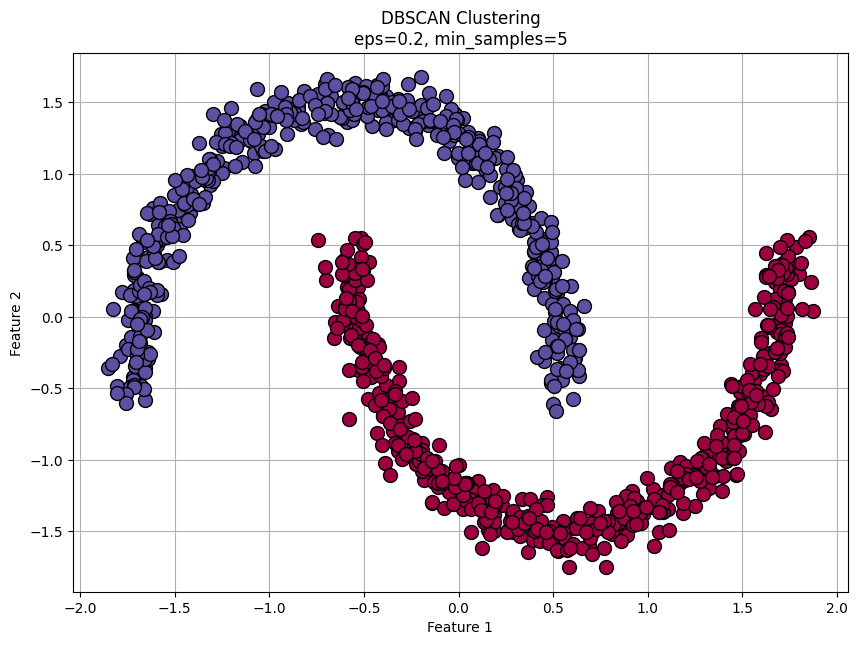

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Membuat mask untuk core samples
core_samples_mask = np.zeros_like(labels, dtype=bool)

# Menandai core samples
core_samples_mask[db.core_sample_indices_] = True

# Mendapatkan label cluster
unique_labels = set(labels)

# Membuat warna untuk setiap cluster
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

# Membuat figure
plt.figure(figsize=(10, 7))

# Menampilkan setiap cluster
for k, col in zip(unique_labels, colors):
    # Noise diberi warna hitam
    if k == -1:
        col = [0, 0, 0, 1]

    # Mask anggota cluster
    class_member_mask = (labels == k)

    # Mengambil core samples
    xy = X_scaled[class_member_mask & core_samples_mask]

    # Menampilkan core samples dengan titik besar
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10)

    # Mengambil non-core samples
    xy = X_scaled[class_member_mask & ~core_samples_mask]

    # Menampilkan non-core samples dengan titik kecil
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=5)

# Judul grafik
plt.title("DBSCAN Clustering\neps=0.2, min_samples=5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

In [32]:
# Daftar nilai eps yang akan diuji
eps_values = [0.05, 0.1, 0.2, 0.3, 0.5]

# min_samples tetap 5
min_samples = 5

# Menyimpan hasil eksperimen
results_eps = []

# Melakukan eksperimen
for eps in eps_values:
    # Membuat model DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples)

    # Melakukan clustering
    labels_exp = db.fit_predict(X_scaled)

    # Menghitung jumlah cluster (mengabaikan noise -1)
    n_clusters = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)

    # Menghitung jumlah noise
    n_noise = list(labels_exp).count(-1)

    # Menghitung metrik
    homogeneity = metrics.homogeneity_score(y, labels_exp)
    completeness = metrics.completeness_score(y, labels_exp)
    v_measure = metrics.v_measure_score(y, labels_exp)
    ari = metrics.adjusted_rand_score(y, labels_exp)
    ami = metrics.adjusted_mutual_info_score(y, labels_exp)

    # Silhouette hanya dihitung jika cluster > 1
    if len(set(labels_exp)) > 1:
        silhouette = metrics.silhouette_score(X_scaled, labels_exp)
    else:
        silhouette = np.nan

    # Menyimpan hasil
    results_eps.append([
        eps, n_clusters, n_noise, homogeneity,
        completeness, v_measure, ari, ami, silhouette
    ])

# Membuat tabel hasil
columns = [
    'eps', 'clusters', 'noise', 'homogeneity',
    'completeness', 'v_measure', 'ARI', 'AMI', 'silhouette'
]

results_eps_df = pd.DataFrame(results_eps, columns=columns)

# Menampilkan dataframe
results_eps_df

,eps,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,61,386,0.615466,0.136931,0.224021,0.015642,0.210259,-0.048518
1,0.10,3,19,0.981343,0.632772,0.769420,0.758440,0.769024,0.290689
2,0.20,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160
3,0.30,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160
4,0.50,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160


In [31]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics

# Nilai min_samples yang akan diuji
min_samples_values = [3, 10, 20]

# eps tetap 0.2
eps = 0.2

# Menyimpan hasil eksperimen
results_min_samples = []

# Melakukan eksperimen
for min_samples in min_samples_values:
    # Membuat model DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples)

    # Melakukan clustering
    labels_exp = db.fit_predict(X_scaled)

    # Menghitung jumlah cluster (mengabaikan noise -1)
    n_clusters = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)

    # Menghitung jumlah noise
    n_noise = list(labels_exp).count(-1)

    # Menghitung metrik
    homogeneity = metrics.homogeneity_score(y, labels_exp)
    completeness = metrics.completeness_score(y, labels_exp)
    v_measure = metrics.v_measure_score(y, labels_exp)
    ari = metrics.adjusted_rand_score(y, labels_exp)
    ami = metrics.adjusted_mutual_info_score(y, labels_exp)

    # Silhouette Score
    if len(set(labels_exp)) > 1:
        silhouette = metrics.silhouette_score(X_scaled, labels_exp)
    else:
        silhouette = np.nan

    # Menyimpan hasil
    results_min_samples.append([
        min_samples, n_clusters, n_noise, homogeneity,
        completeness, v_measure, ari, ami, silhouette
    ])

# Membuat DataFrame
columns = [
    'min_samples', 'clusters', 'noise', 'homogeneity',
    'completeness', 'v_measure', 'ARI', 'AMI', 'silhouette'
]

results_min_samples_df = pd.DataFrame(results_min_samples, columns=columns)

# Menampilkan dataframe
results_min_samples_df

,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,3,2,0,1.0,1.000000,1.000000,1.00000,1.000000,0.39116
1,10,2,0,1.0,1.000000,1.000000,1.00000,1.000000,0.39116
2,20,2,3,1.0,0.974224,0.986944,0.99403,0.986923,0.02758


Berdasarkan percobaan DBSCAN pada dataset make_moons, perubahan nilai eps dan min_samples memengaruhi jumlah cluster, jumlah data yang dianggap noise, serta nilai metrik evaluasi. Nilai eps yang terlalu kecil cenderung menyebabkan lebih banyak data dianggap sebagai noise, sedangkan peningkatan eps dapat membuat lebih banyak titik tergabung ke dalam cluster. Perubahan min_samples juga memengaruhi kepadatan minimum yang diperlukan agar suatu titik dianggap sebagai core sample. Kualitas clustering kemudian dibandingkan menggunakan Homogeneity, Completeness, V-measure, ARI, AMI, dan Silhouette.